# Stage 09 — Homework Starter Notebook

In the lecture, we learned how to create engineered features. Now it’s your turn to apply those ideas to your own project data.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib

In [2]:
%matplotlib inline
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Make src/ importable when this notebook is run from homework09/.
if str(Path.cwd()) not in sys.path:
    sys.path.insert(0, str(Path.cwd()))

from src.features import spend_income_ratio, disposable_income, encode_region

# Example synthetic data (replace with your project dataset).
np.random.seed(0)
n = 100
df = pd.DataFrame({
    'income': np.random.normal(60000, 15000, n).astype(int),
    'monthly_spend': np.random.normal(2000, 600, n).astype(int),
    'credit_score': np.random.normal(680, 50, n).astype(int),
    'region': np.random.choice(['North', 'South', 'East', 'West'], n),
    'default_flag': np.random.choice([0, 1], n, p=[0.8, 0.2]),
})
df.head()

,income,monthly_spend,credit_score,region,default_flag
0,86460,3129,661,East,0
1,66002,1191,668,North,0
2,74681,1237,734,West,0
3,93613,2581,712,South,1
4,88013,1296,712,East,1


## Engineered features — one is worked below; add at least two more

At least one of yours must encode a categorical column. `region` is the categorical
column here; the lecture shows three ways to encode it (one-hot, label, frequency).

In [3]:
# Feature 1 of 3 (worked example) — spending relative to income.
df['spend_income_ratio'] = spend_income_ratio(df, 'monthly_spend', 'income')
# equivalent one-liner: df['monthly_spend'] / df['income']
df[['income', 'monthly_spend', 'spend_income_ratio']].head()

,income,monthly_spend,spend_income_ratio
0,86460,3129,0.036190
1,66002,1191,0.018045
2,74681,1237,0.016564
3,93613,2581,0.027571
4,88013,1296,0.014725


### Rationale for Feature 1 — `spend_income_ratio`

- **What**: spending as a fraction of income (`monthly_spend / income`).
- **Why it helps**: raw `monthly_spend` is not comparable across people — a $2,000
  monthly spend is trivial for someone earning $80k but serious for someone earning
  $40k. Dividing by income makes spending *relative*, which is what actually drives
  default risk, not the absolute dollar amount.
- **EDA link**: Stage 08 showed `income` and `spend` are right-skewed with outliers;
  the ratio is more stable than either raw column and partly normalizes that skew.

In [4]:
# Feature 2 of 3 — money left after monthly spending.
df['disposable_income'] = disposable_income(df, 'income', 'monthly_spend')
df[['income', 'monthly_spend', 'disposable_income']].head()

,income,monthly_spend,disposable_income
0,86460,3129,83331
1,66002,1191,64811
2,74681,1237,73444
3,93613,2581,91032
4,88013,1296,86717


### Rationale for Feature 2 — `disposable_income`

- **What**: income minus monthly spend (`income - monthly_spend`) — the surplus
  left to service debt after living costs.
- **Why it helps**: two people with the same income but different spend have very
  different capacity to absorb a missed payment. `disposable_income` captures the
  gap that neither raw column captures alone.
- **EDA link**: Stage 08's distribution plots showed `income` and `spend` both vary
  widely and independently, so their *difference* (not either level) is the relevant
  signal for default risk.

In [5]:
# Feature 3 of 3 — one-hot encode the categorical column `region`.
#   drop_first=True avoids the dummy-variable trap (perfect collinearity with the
#   intercept). See the rationale cell below for why one-hot over label/frequency.
df = encode_region(df, col='region', method='onehot', drop_first=True)
df.head()

,income,monthly_spend,credit_score,default_flag,spend_income_ratio,disposable_income,region_North,region_South,region_West
0,86460,3129,661,0,0.036190,83331,False,False,False
1,66002,1191,668,0,0.018045,64811,True,False,False
2,74681,1237,734,0,0.016564,73444,False,False,True
3,93613,2581,712,1,0.027571,91032,False,True,False
4,88013,1296,712,1,0.014725,86717,False,False,False


### Rationale for Feature 3 — one-hot encoding of `region`

- **Why encode at all**: `region` is categorical text; most models need numbers.
- **Why one-hot over label**: label encoding maps North/South/East/West to 0/1/2/3,
  which *imposes a false ordering* (it claims East > North) that a linear model
  would misinterpret. One-hot treats each region as an independent flag with no
  implied order.
- **Why one-hot over frequency**: here the four regions are (by construction)
  roughly balanced, so frequency encoding would produce a near-constant column
  (~0.25 everywhere) with almost no variance — it would throw the signal away.
  One-hot keeps the real information.
- **Why `drop_first=True`**: with an intercept, keeping all four dummies is
  perfectly collinear; dropping one leaves the same information in 3 columns.
- **EDA link**: Stage 08 found `region` balanced and usable as a categorical
  feature; this is the stage-09 step that turns it into model-ready columns.

## Correlation check — do the new features relate to the target?

Compare every engineered column against `default_flag`.

Pearson correlation with default_flag:
region_West          -0.049
spend_income_ratio   -0.036
region_North          0.009
monthly_spend         0.071
disposable_income     0.131
income                0.133
region_South          0.153
credit_score          0.161
Name: default_flag, dtype: float64


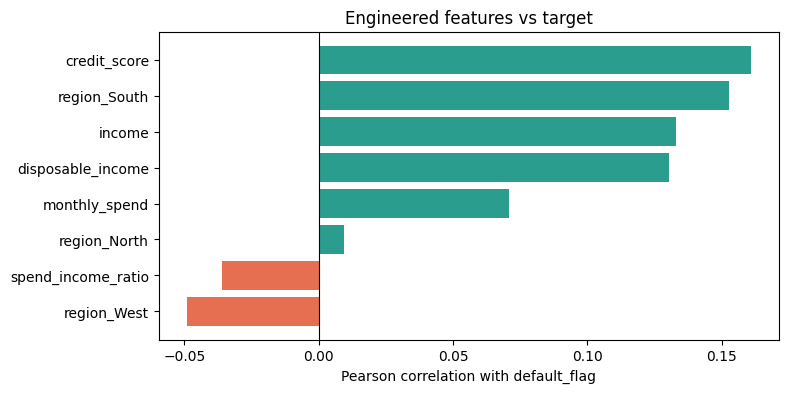

In [6]:
# Correlation of every (now-engineered) column with the target.
corr = df.corr(numeric_only=True)['default_flag'].drop('default_flag').sort_values()

print('Pearson correlation with default_flag:')
print(corr.round(3))

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(corr.index, corr.values,
        color=np.where(corr.values >= 0, '#2a9d8f', '#e76f51'))
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson correlation with default_flag')
ax.set_title('Engineered features vs target')
plt.show()

### What the correlation check tells us

- Every correlation with `default_flag` is **weak** (|r| ≤ 0.16). That is
  expected, and is a property of the *synthetic generator*: `default_flag` is drawn
  independently of the predictors (`np.random.choice([0,1], p=[0.8,0.2])`).
- The point of this plot is the **mechanics** — it shows how to test whether a new
  feature carries signal for the target *before* feeding it to a model. On real
  credit data we would expect `spend_income_ratio` and `credit_score` to show a
  measurable correlation with default, and we would keep features with |r| above a
  small threshold (or that survive a univariate selection test) and drop the rest.
- It also confirms the features are **not trivially collinear**: `disposable_income`
  and `spend_income_ratio` are both derived from the raw income/spend columns yet
  capture different information, so none is an exact copy of another.